The official submission notebooks for the ARC-AGI3 competition involve lots of code in the ARC-AGI-3-agents repository, and are not straightforward to adapt to running on the training set of 25 games. This notebook demonstrates a simplified submission approach (using a random solver as an example) that runs on the 25 training games when not submitting, and on the 110 test games when submitting.

To use your own solution, edit the play function. You may also want to change the way the games are parallelized in the final cell (the example just runs them all in series, without any parallelization).

You should also be able to use this notebook offline, outside the Kaggle environment. Skip the first cell; rather, install all necessary packages through pip or uv. You'll need to adjust paths throughout the notebook to match your local environment (and download the environment files from the competition dataset).

In [1]:
# Install modules
!pip install --no-index --find-links \
    /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels \
    arc-agi python-dotenv

Looking in links: /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/arc_agi-0.9.6-py3-none-any.whl
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/arcengine-0.9.3-py3-none-any.whl (from arc-agi)
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/pillow-12.1.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (from arc-agi)
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatib

The following cell contains the actual solver agent, doing 1000 random moves per game. It also shows the initial state of each game as an example.

In [2]:
import asyncio
import random
import numpy as np
import arc_agi
from arcengine import GameAction, GameState
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

MAX_MOVES = 1000
SEED = 42
# ARC color palette (0-15)
ARC_COLORS: dict[int, tuple[float, float, float]] = {
    0: (1.0, 1.0, 1.0),
    1: (0.8, 0.8, 0.8),
    2: (0.6, 0.6, 0.6),
    3: (0.4, 0.4, 0.4),
    4: (0.2, 0.2, 0.2),
    5: (0.0, 0.0, 0.0),
    6: (0.898, 0.227, 0.639),
    7: (1.0, 0.482, 0.8),
    8: (0.976, 0.235, 0.192),
    9: (0.118, 0.576, 1.0),
    10: (0.533, 0.847, 0.945),
    11: (1.0, 0.863, 0.0),
    12: (1.0, 0.522, 0.106),
    13: (0.573, 0.071, 0.192),
    14: (0.310, 0.800, 0.188),
    15: (0.639, 0.337, 0.839),
}
ARC_CMAP = mcolors.ListedColormap([ARC_COLORS[i] for i in range(16)])
import matplotlib.pyplot as plt

def play(env, game_id):
    """Play random moves on an environment until WIN or max moves."""
    rng = random.Random(SEED)
    response = env._last_response

    for moves in range(1, MAX_MOVES + 1):

        if moves%500==0:
            # Show the game state
            plt.imshow(response.frame[-1], cmap=ARC_CMAP, 
                       vmin=0, vmax=15, interpolation='none', aspect='equal')
            plt.title(f'{game_id} after {moves} moves, {response.levels_completed} levels completed')
            plt.show()
            
            

        if response.state == GameState.WIN:
            break

        # Reset on GAME_OVER or NOT_PLAYED via RESET action
        if response.state in (GameState.GAME_OVER, GameState.NOT_PLAYED):
            response = env.step(GameAction.RESET, {})
            if response is None:
                break
            continue

        # Pick a random non-reset action
        all_actions = [a for a in GameAction if a is not GameAction.RESET]
        action = rng.choice(all_actions)

        data = {}
        if action.is_complex() and response.frame:
            frame = response.frame[-1]
            # Pick a random color present in the frame, then a random pixel of that color
            color = rng.choice(np.unique(frame).tolist())
            ys, xs = np.where(frame == color)
            idx = rng.randint(0, len(xs) - 1)
            data = {"x": int(xs[idx]), "y": int(ys[idx])}

        # Do the move
        response = env.step(action,data)

    state = response.state.name if response else "unknown"
    levels = response.levels_completed if response else 0
    return f"{game_id}: {moves} moves, state={state}, levels_completed={levels}"

2026-03-31 07:41:58 | INFO | Created new scorecard: 461afd57-436d-4e55-8ad9-f524e4788e84
2026-03-31 07:41:58 | INFO | Successfully loaded game class Sk48 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/sk48/41055498/sk48.py


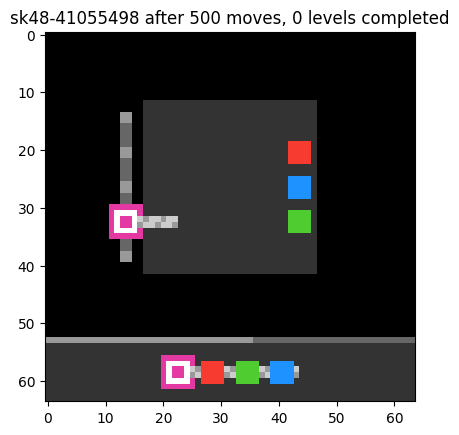

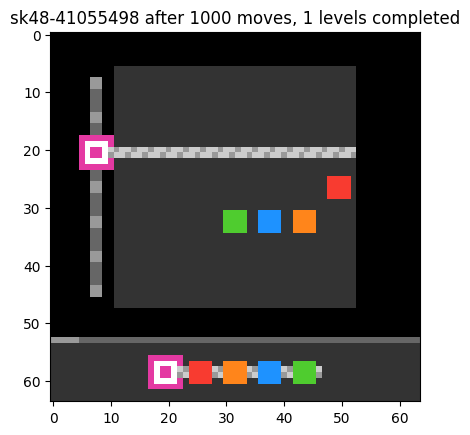

2026-03-31 07:41:59 | INFO | Successfully loaded game class Tn36 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/tn36/ab4f63cc/tn36.py


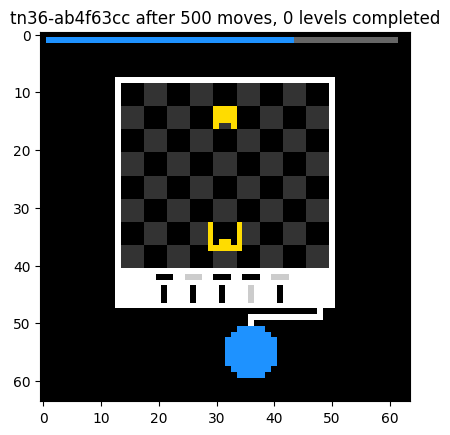

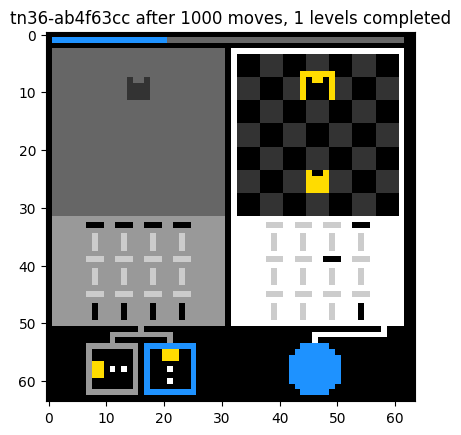

2026-03-31 07:42:00 | INFO | Successfully loaded game class M0r0 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/m0r0/dadda488/m0r0.py


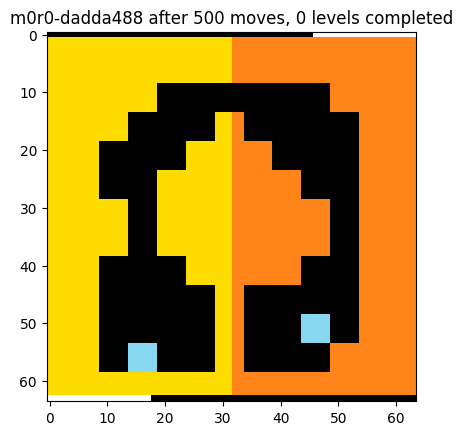

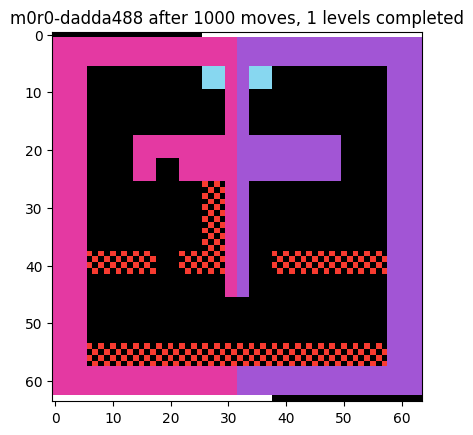

2026-03-31 07:42:01 | INFO | Successfully loaded game class Bp35 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/bp35/0a0ad940/bp35.py


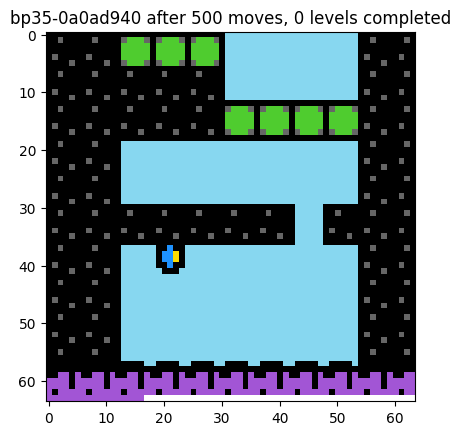

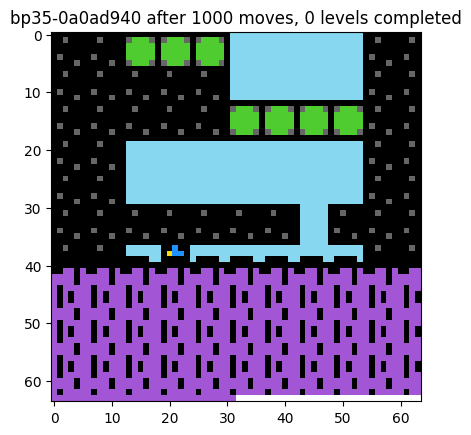

2026-03-31 07:42:03 | INFO | Successfully loaded game class Cn04 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/cn04/65d47d14/cn04.py


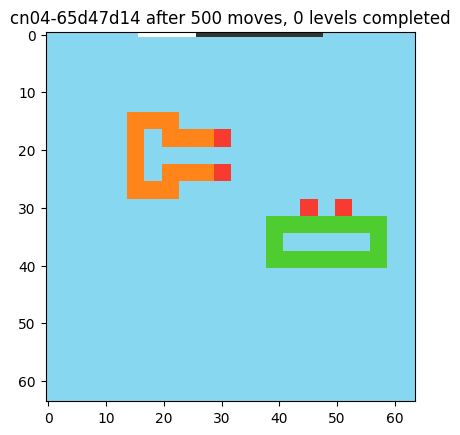

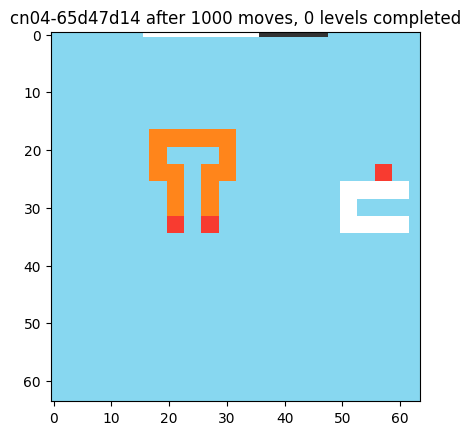

2026-03-31 07:42:04 | INFO | Successfully loaded game class Dc22 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/dc22/4c9bff3e/dc22.py


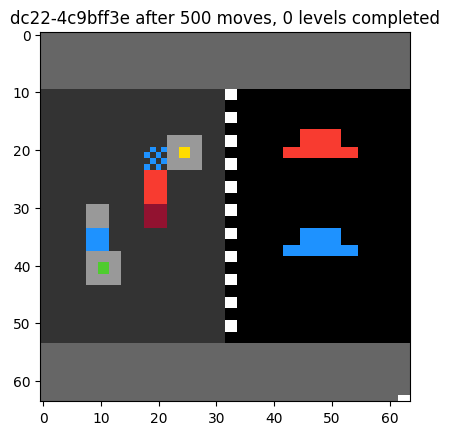

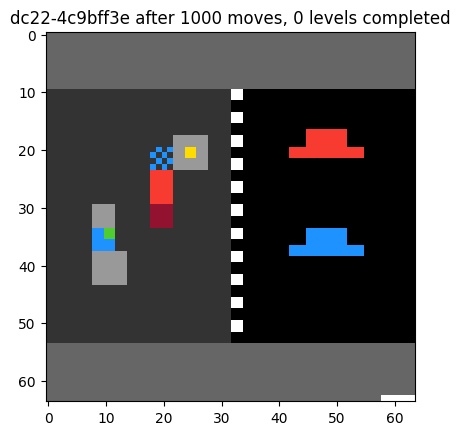

2026-03-31 07:42:05 | INFO | Successfully loaded game class Tu93 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/tu93/2b534c15/tu93.py


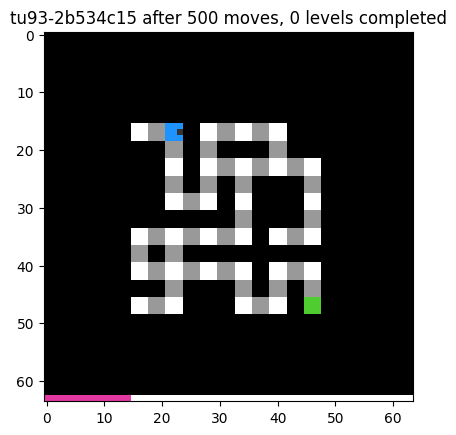

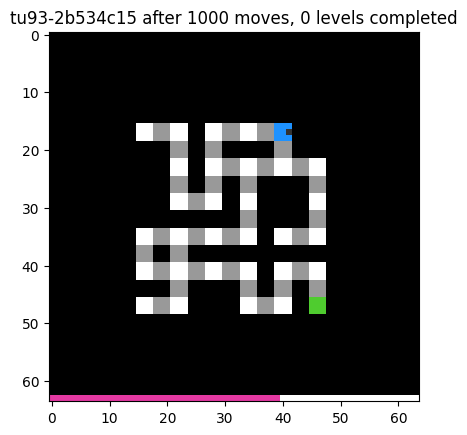

2026-03-31 07:42:05 | INFO | Successfully loaded game class Lp85 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/lp85/305b61c3/lp85.py


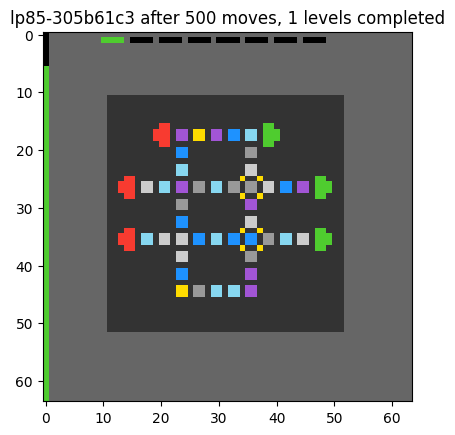

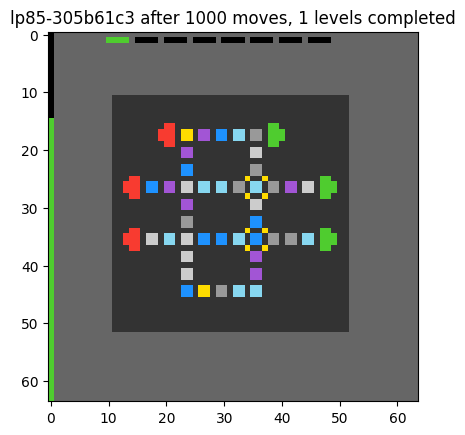

2026-03-31 07:42:06 | INFO | Successfully loaded game class Ka59 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/ka59/9f096b4a/ka59.py


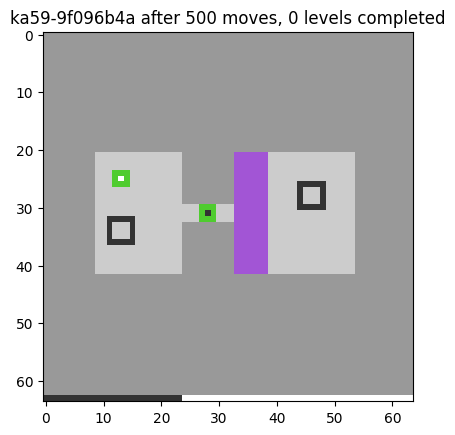

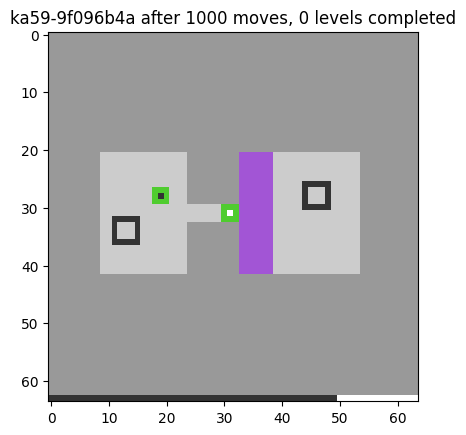

2026-03-31 07:42:07 | INFO | Successfully loaded game class Wa30 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/wa30/ee6fef47/wa30.py


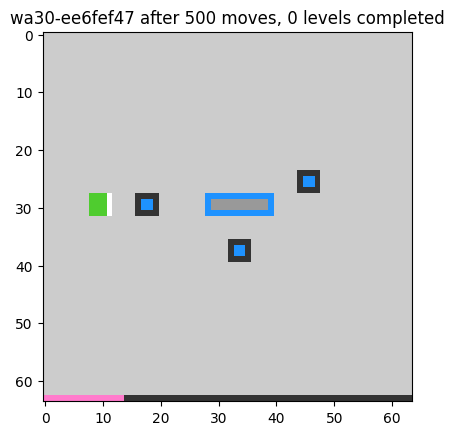

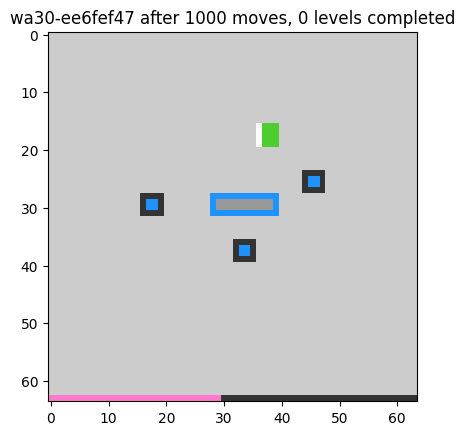

2026-03-31 07:42:07 | INFO | Successfully loaded game class Vc33 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/vc33/9851e02b/vc33.py


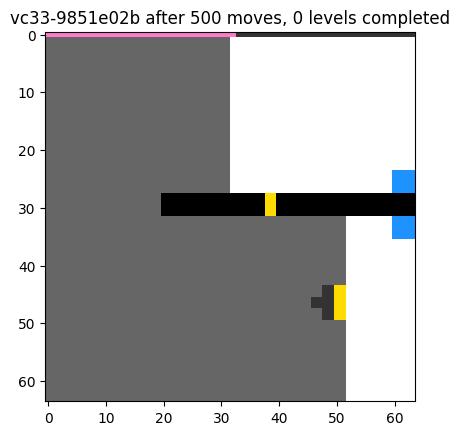

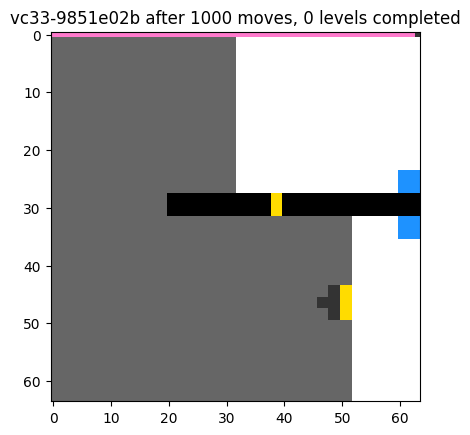

2026-03-31 07:42:08 | INFO | Successfully loaded game class Lf52 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/lf52/271a04aa/lf52.py


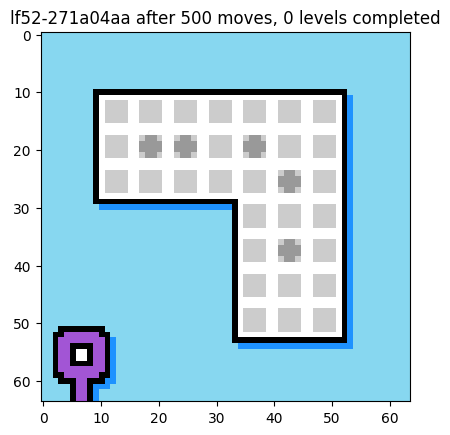

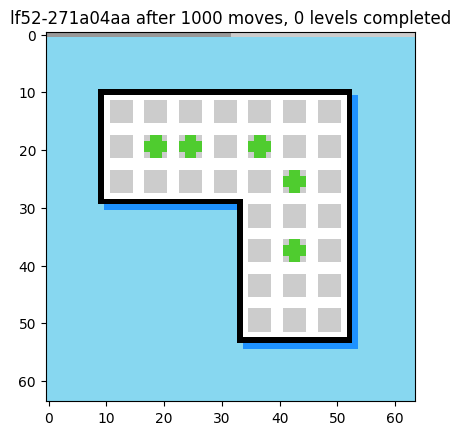

2026-03-31 07:42:10 | INFO | Successfully loaded game class R11l from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/r11l/aa269680/r11l.py


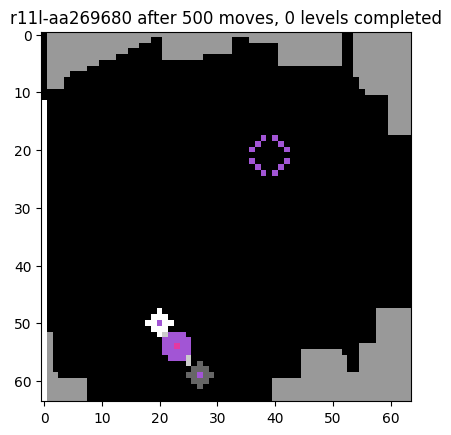

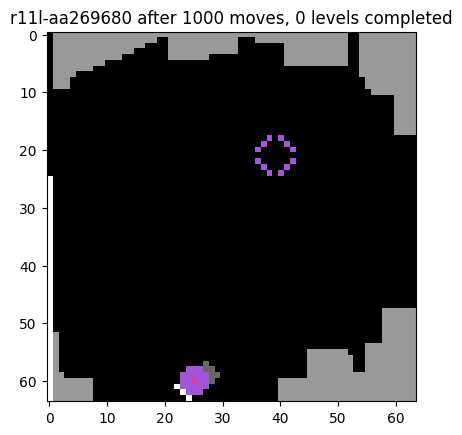

2026-03-31 07:42:10 | INFO | Successfully loaded game class Sc25 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/sc25/f9b21a2f/sc25.py


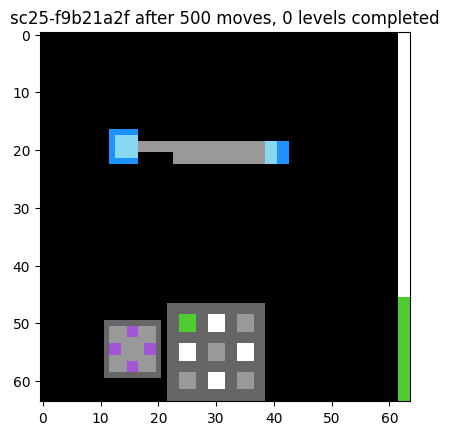

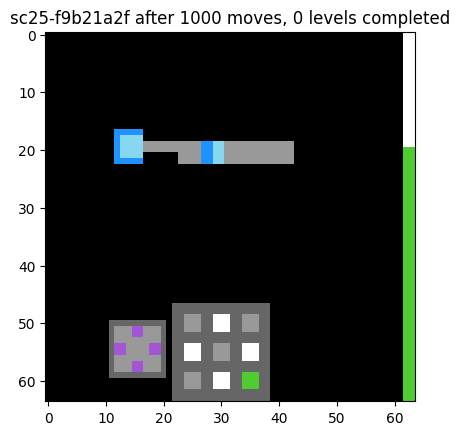

2026-03-31 07:42:12 | INFO | Successfully loaded game class Sp80 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/sp80/0ee2d095/sp80.py


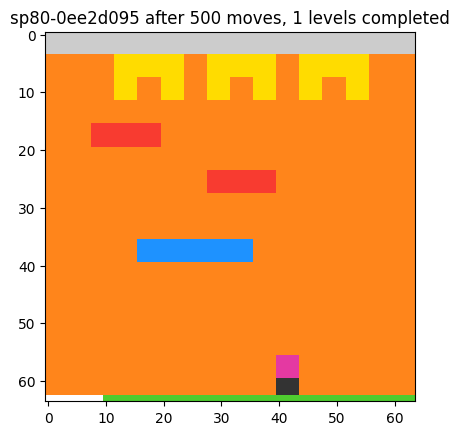

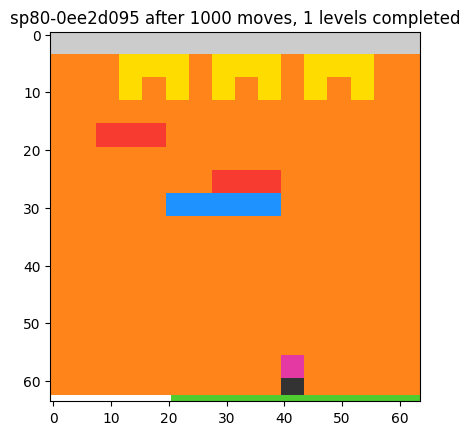

2026-03-31 07:42:13 | INFO | Successfully loaded game class Ar25 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/ar25/e3c63847/ar25.py


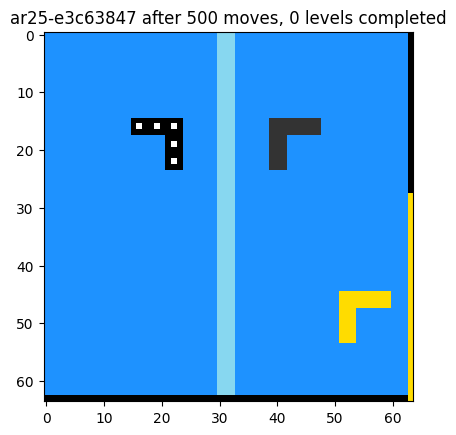

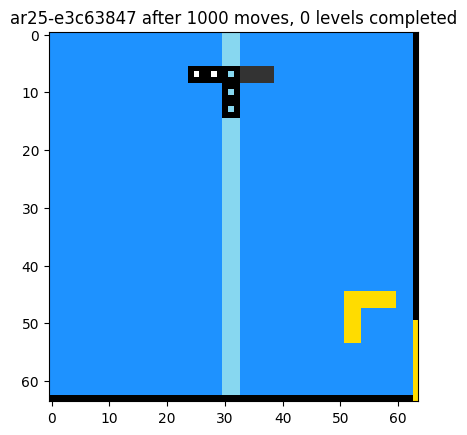

2026-03-31 07:42:13 | INFO | Successfully loaded game class Sb26 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/sb26/7fbdac44/sb26.py


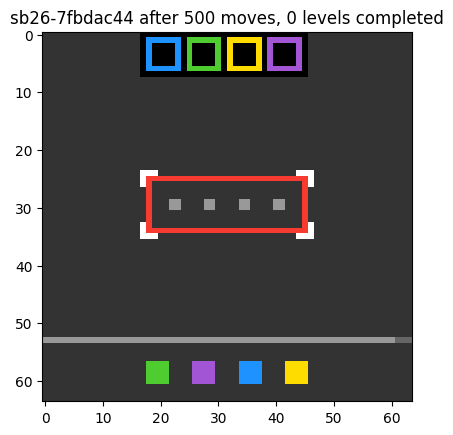

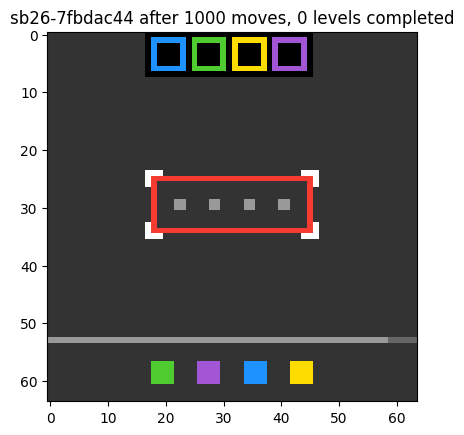

2026-03-31 07:42:14 | INFO | Successfully loaded game class Cd82 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/cd82/fb555c5d/cd82.py


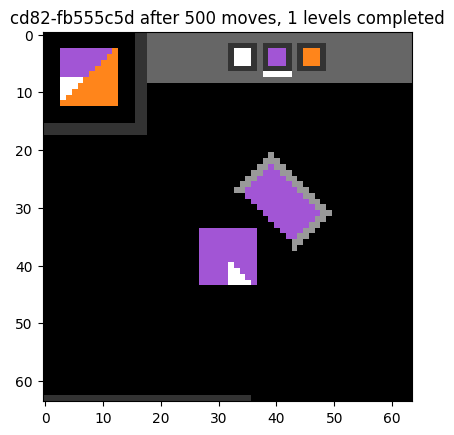

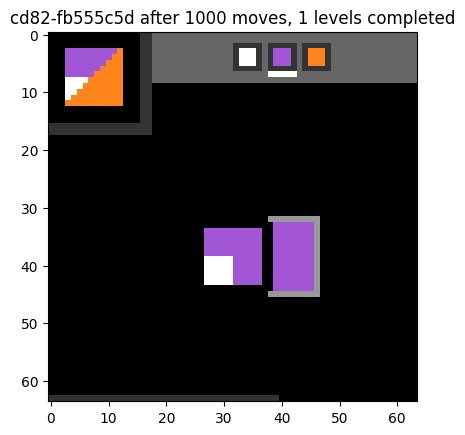

2026-03-31 07:42:15 | INFO | Successfully loaded game class Re86 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/re86/4e57566e/re86.py


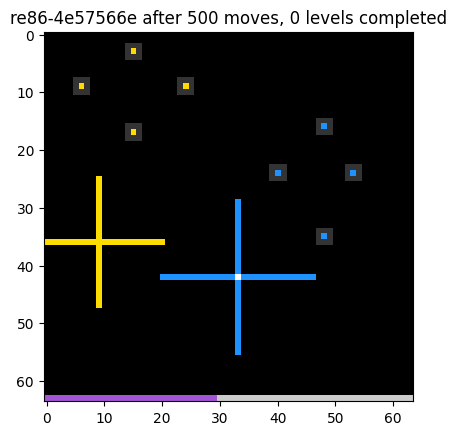

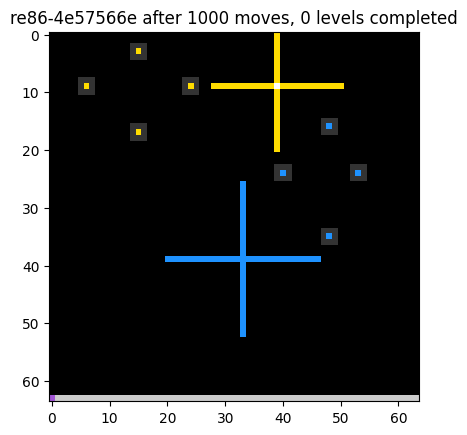

2026-03-31 07:42:16 | INFO | Successfully loaded game class S5i5 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/s5i5/a48e4b1d/s5i5.py


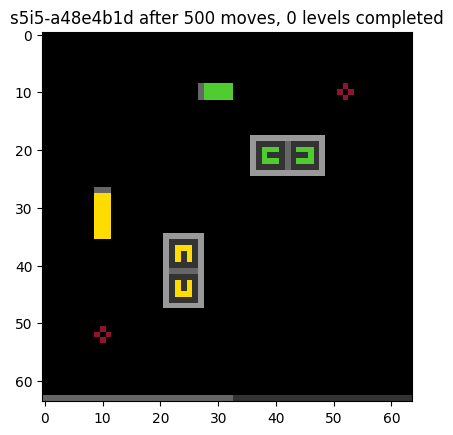

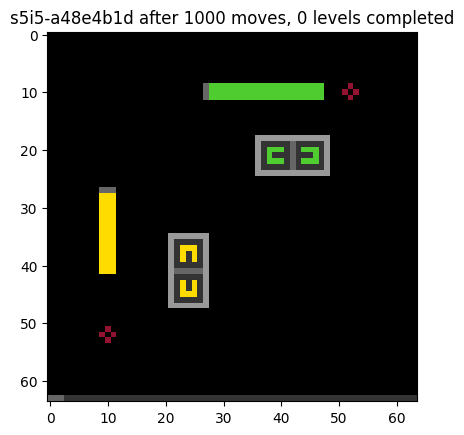

2026-03-31 07:42:16 | INFO | Successfully loaded game class Ls20 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/ls20/9607627b/ls20.py


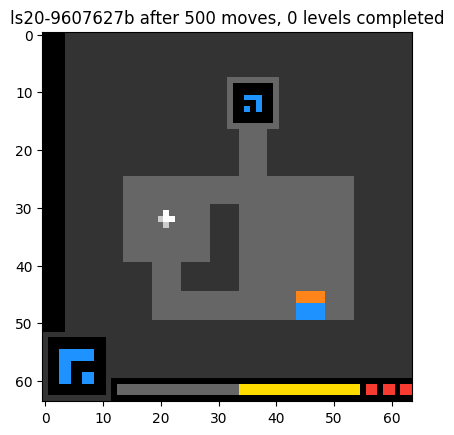

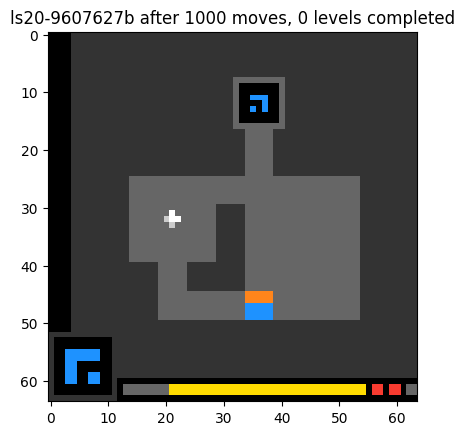

2026-03-31 07:42:18 | INFO | Successfully loaded game class Ft09 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/ft09/0d8bbf25/ft09.py


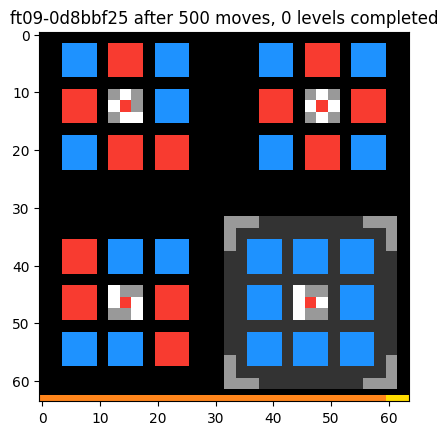

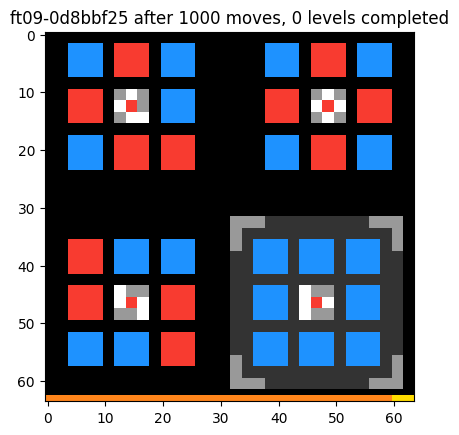

2026-03-31 07:42:18 | INFO | Successfully loaded game class Su15 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/su15/4c352900/su15.py


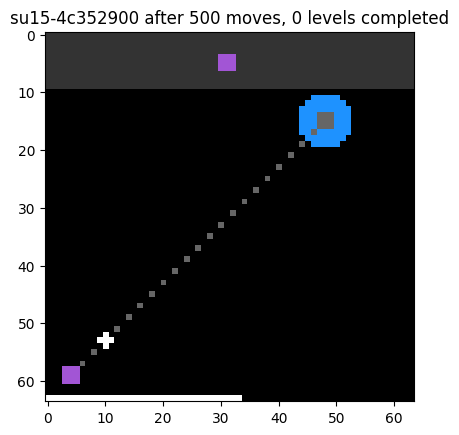

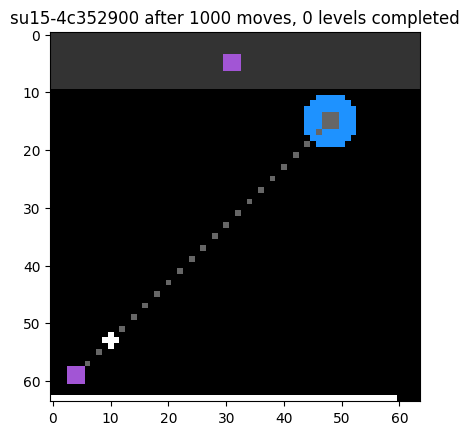

2026-03-31 07:42:19 | INFO | Successfully loaded game class Tr87 from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/tr87/cd924810/tr87.py


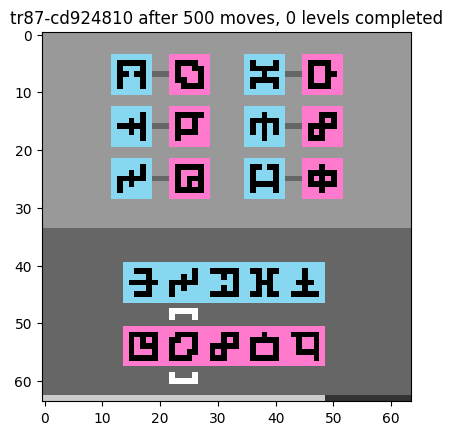

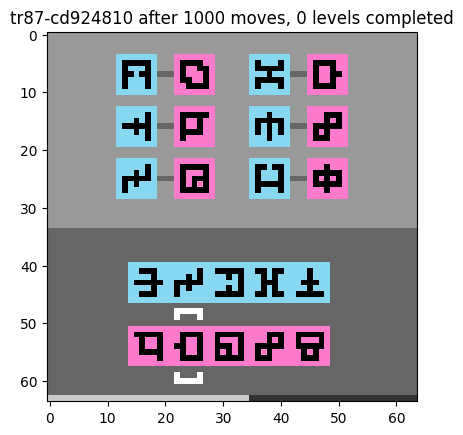

2026-03-31 07:42:20 | INFO | Successfully loaded game class G50t from /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/g50t/5849a774/g50t.py


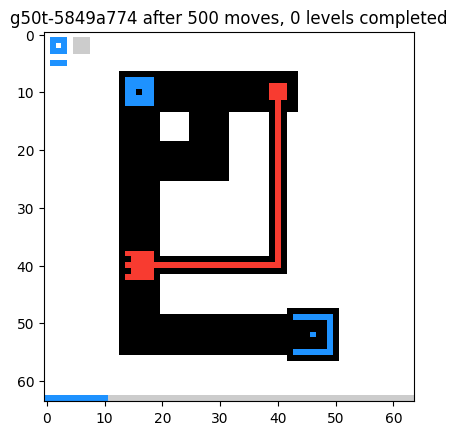

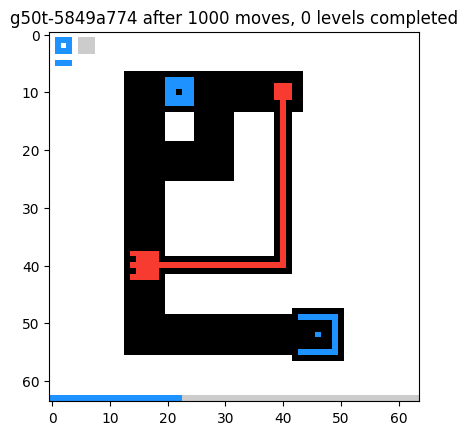

sk48-41055498: 1000 moves, state=NOT_FINISHED, levels_completed=1
tn36-ab4f63cc: 1000 moves, state=NOT_FINISHED, levels_completed=1
m0r0-dadda488: 1000 moves, state=NOT_FINISHED, levels_completed=1
bp35-0a0ad940: 1000 moves, state=NOT_FINISHED, levels_completed=0
cn04-65d47d14: 1000 moves, state=NOT_FINISHED, levels_completed=0
dc22-4c9bff3e: 1000 moves, state=NOT_FINISHED, levels_completed=0
tu93-2b534c15: 1000 moves, state=NOT_FINISHED, levels_completed=0
lp85-305b61c3: 1000 moves, state=NOT_FINISHED, levels_completed=1
ka59-9f096b4a: 1000 moves, state=NOT_FINISHED, levels_completed=0
wa30-ee6fef47: 1000 moves, state=NOT_FINISHED, levels_completed=0
vc33-9851e02b: 1000 moves, state=NOT_FINISHED, levels_completed=0
lf52-271a04aa: 1000 moves, state=NOT_FINISHED, levels_completed=0
r11l-aa269680: 1000 moves, state=NOT_FINISHED, levels_completed=0
sc25-f9b21a2f: 1000 moves, state=NOT_FINISHED, levels_completed=0
sp80-0ee2d095: 1000 moves, state=NOT_FINISHED, levels_completed=1
ar25-e3c63

In [3]:
import os
import arc_agi

if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    # Submission: start arcade via gateway
    
    # Wait for gateway to be ready
    !curl --fail --retry 999 --retry-all-errors --retry-delay 5 \
          --retry-max-time 600 http://gateway:8001/api/games
    
    with open('/kaggle/working/.env', 'w') as f:
            f.write("""SCHEME=http
            HOST=gateway
            PORT=8001
            ARC_API_KEY=test-key-123
            ARC_BASE_URL=http://gateway:8001/
            OPERATION_MODE=online
            ENVIRONMENTS_DIR=
            RECORDINGS_DIR=/kaggle/working/server_recording
            """)
else:
    # Offline run: start arcade locally
    with open('/kaggle/working/.env', 'w') as f:
            f.write("""SCHEME=http
            HOST=gateway
            PORT=8001
            ARC_API_KEY=test-key-123
            ARC_BASE_URL=http://gateway:8001/
            OPERATION_MODE=offline
            ENVIRONMENTS_DIR=/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/
            RECORDINGS_DIR=/kaggle/working/server_recording
            """)

# Start arcade    
import dotenv
dotenv.load_dotenv(dotenv_path=".env", override=True)
arcade = arc_agi.Arcade()

# Run all games concurrently
results = [play(arcade.make(env_info.game_id), env_info.game_id) 
           for env_info in arcade.available_environments]
print("\n".join(results))

if not os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    # Show scorecard
    print(f"\n{'='*60}")
    scorecard = arcade.get_scorecard()
    print(f"\n{'='*60}")
    print(f"Score: {scorecard.score:.4f}")
    print(f"Environments: {scorecard.total_environments_completed}/{scorecard.total_environments}")
    print(f"Levels completed: {scorecard.total_levels_completed}/{scorecard.total_levels}")
    print(f"Total actions: {scorecard.total_actions}")
    print(f"\nPer-environment breakdown:")
    print(f"{'Game':<20} {'Score':>8} {'Levels':>10} {'Actions':>10} {'Done':>6}")
    print(f"{'-'*20} {'-'*8} {'-'*10} {'-'*10} {'-'*6}")
    for env_score in scorecard.environments:
        print(
            f"{env_score.id:<20} {env_score.score:>8.2f} "
            f"{env_score.levels_completed:>10} {env_score.actions:>10} "
            f"{'Y' if env_score.completed else 'N':>6}"
        )
    if scorecard.tags_scores:
        print(f"\nPer-tag breakdown:")
        for tag_score in scorecard.tags_scores:
            print(f"  {tag_score.id}: score={tag_score.score:.4f}, levels={tag_score.levels_completed}, envs={tag_score.number_of_environments}")

    # Dummy submission
    submission = pd.DataFrame(
        data=[['1_0', '1', True, 1]],
        columns=['row_id', 'game_id', 'end_of_game', 'score'])
    submission.to_parquet('/kaggle/working/submission.parquet', index=False)